# Курсова робота

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from entsoe import EntsoePandasClient
from config import ENTSOE_TOKEN

client = EntsoePandasClient(api_key=ENTSOE_TOKEN)

country_code = 'FR'

start_normal = pd.Timestamp('2017-01-01', tz='Europe/Paris')
end_normal = pd.Timestamp('2020-01-01', tz='Europe/Paris')

start_crisis = pd.Timestamp('2020-01-01', tz='Europe/Paris')
end_crisis = pd.Timestamp('2023-01-01', tz='Europe/Paris')

print("Завантажуємо стабільні дані Франції (2017-2019)...")
try:
    df_normal = client.query_load(country_code, start=start_normal, end=end_normal)
    df_normal.columns = ['Energy_Consumption']
    df_normal.to_csv('data/fr_energy_normal.csv')
    print(f"Успіх! Записів: {len(df_normal)}")
    print(f"Пропусків (NaN): {df_normal['Energy_Consumption'].isna().sum()}")
    print(f"Перші значення:\n{df_normal.head()}")
    print(f"Статистика:\n{df_normal.describe()}\n")
except Exception as e:
    print(f"Помилка: {e}\n")

print("Завантажуємо кризові дані Франції (2020-2022)...")
try:
    df_crisis = client.query_load(country_code, start=start_crisis, end=end_crisis)
    df_crisis.columns = ['Energy_Consumption']
    df_crisis.to_csv('data/fr_energy_crisis.csv')
    print(f"Успіх! Записів: {len(df_crisis)}")
    print(f"Пропусків (NaN): {df_crisis['Energy_Consumption'].isna().sum()}")
    print(f"Перші значення:\n{df_crisis.head()}")
    print(f"Статистика:\n{df_crisis.describe()}")
except Exception as e:
    print(f"Помилка: {e}")

Завантажуємо стабільні дані Франції (2017-2019)...
Успіх! Записів: 26234
Пропусків (NaN): 0
Перші значення:
                           Energy_Consumption
2017-01-01 00:00:00+01:00             75140.0
2017-01-01 01:00:00+01:00             73330.0
2017-01-01 02:00:00+01:00             71806.0
2017-01-01 03:00:00+01:00             68195.0
2017-01-01 04:00:00+01:00             65672.0
Статистика:
       Energy_Consumption
count        26234.000000
mean         53880.082450
std          11857.018637
min          30630.000000
25%          44961.250000
50%          52049.500000
75%          61835.750000
max          94492.000000

Завантажуємо кризові дані Франції (2020-2022)...
Успіх! Записів: 26270
Пропусків (NaN): 0
Перші значення:
                           Energy_Consumption
2020-01-01 00:00:00+01:00             64677.0
2020-01-01 01:00:00+01:00             63142.0
2020-01-01 02:00:00+01:00             61612.0
2020-01-01 03:00:00+01:00             58419.0
2020-01-01 04:00:00+01:00        

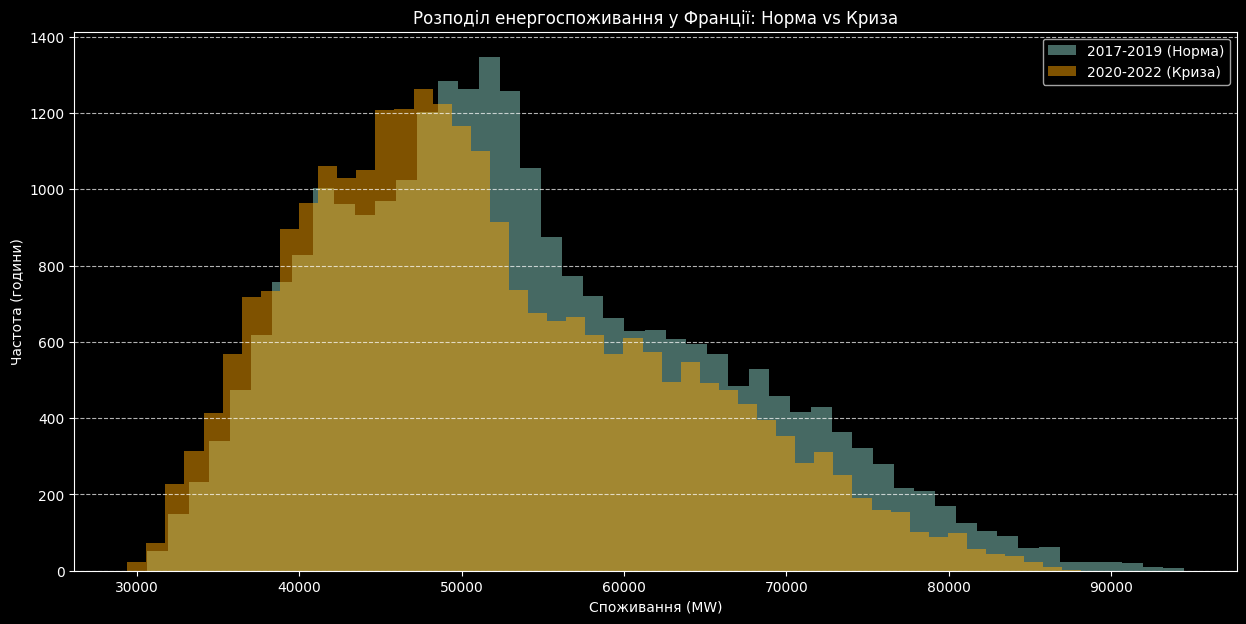

Середньомісячне споживання під час локдауну (березень-травень 2020):
2020-03-31 00:00:00+00:00    55230.276882
2020-04-30 00:00:00+00:00    42409.579167
2020-05-31 00:00:00+00:00    40946.911290
Freq: ME, Name: Energy_Consumption, dtype: float64


In [2]:
# Завантажуємо дані з конвертацією в UTC
df_normal = pd.read_csv('data/fr_energy_normal.csv', index_col=0)
df_normal.index = pd.to_datetime(df_normal.index, utc=True)

df_crisis = pd.read_csv('data/fr_energy_crisis.csv', index_col=0)
df_crisis.index = pd.to_datetime(df_crisis.index, utc=True)

# Створюємо графік
plt.figure(figsize=(15, 7))

plt.hist(df_normal['Energy_Consumption'], bins=50, alpha=0.5, label='2017-2019 (Норма)')
plt.hist(df_crisis['Energy_Consumption'], bins=50, alpha=0.5, label='2020-2022 (Криза)', color='orange')

plt.title('Розподіл енергоспоживання у Франції: Норма vs Криза')
plt.xlabel('Споживання (MW)')
plt.ylabel('Частота (години)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Середньомісячне споживання
monthly_normal = df_normal['Energy_Consumption'].resample('ME').mean()
monthly_crisis = df_crisis['Energy_Consumption'].resample('ME').mean()

print("Середньомісячне споживання під час локдауну (березень-травень 2020):")
print(monthly_crisis['2020-03':'2020-05'])

Аналіз впливу пандемії (2020 vs 2019):
Місяць  2019 (MW)  2020 (MW)  Зміна (%)
   Січ   71653.07   65836.86      -8.12
   Лют   64792.19   61413.23      -5.22
   Бер   57063.74   55230.28      -3.21
  Квіт   52294.57   42409.58     -18.90
  Трав   47382.02   40946.91     -13.58
  Черв   44931.13   42210.10      -6.06
   Лип   46276.60   43976.92      -4.97
  Серп   42090.66   41663.27      -1.02
   Вер   44486.91   44449.32      -0.08
  Жовт   48086.56   50852.65       5.75
  Лист   60150.70   55082.28      -8.43
  Груд   62044.23   63402.73       2.19


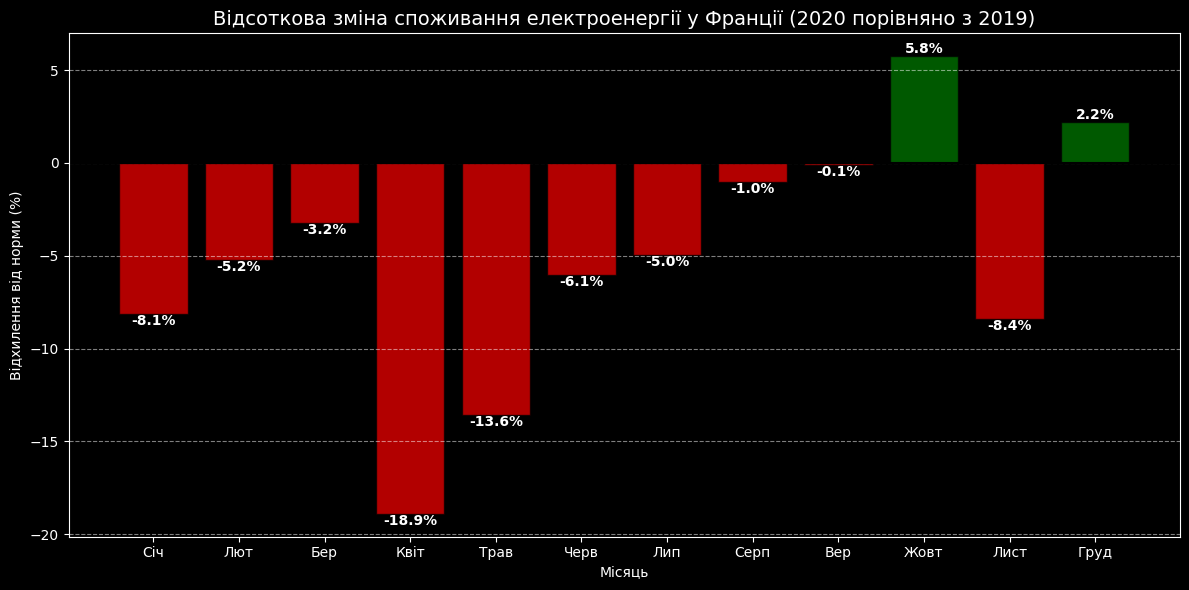

In [3]:
# 1. Завантаження даних та підготовка часових міток
df_normal = pd.read_csv('data/fr_energy_normal.csv', index_col=0)
df_normal.index = pd.to_datetime(df_normal.index, utc=True)

df_crisis = pd.read_csv('data/fr_energy_crisis.csv', index_col=0)
df_crisis.index = pd.to_datetime(df_crisis.index, utc=True)

# 2. Розрахунок середньомісячних значень
monthly_normal = df_normal['Energy_Consumption'].resample('ME').mean()
monthly_crisis = df_crisis['Energy_Consumption'].resample('ME').mean()

# 3. Виділяємо дані за повний 2019 та 2020 роки (12 місяців)
# Переконуємось, що беремо значення як масиви для легкого порівняння
m_2019 = monthly_normal.loc['2019-01-01':'2019-12-31'].values
m_2020 = monthly_crisis.loc['2020-01-01':'2020-12-31'].values

months_labels = ['Січ', 'Лют', 'Бер', 'Квіт', 'Трав', 'Черв',
                 'Лип', 'Серп', 'Вер', 'Жовт', 'Лист', 'Груд']

# 4. Розрахунок відсоткової різниці за формулою:
# Δ = ((Значення_2020 - Значення_2019) / Значення_2019) * 100
diff_percent = ((m_2020 - m_2019) / m_2019) * 100

# 5. Створення фінальної таблиці для виведення
comparison_df = pd.DataFrame({
    'Місяць': months_labels,
    '2019 (MW)': m_2019,
    '2020 (MW)': m_2020,
    'Зміна (%)': diff_percent
})

print("Аналіз впливу пандемії (2020 vs 2019):")
print(comparison_df.round(2).to_string(index=False))

# 6. Візуалізація "Глибини падіння"
plt.figure(figsize=(12, 6))

# Фарбуємо стовпчики: червоний, якщо споживання впало, зелений — якщо зросло
colors = ['red' if x < 0 else 'green' for x in diff_percent]

bars = plt.bar(months_labels, diff_percent, color=colors, alpha=0.7, edgecolor='black')

# Додаємо нульову лінію
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

# Додаємо цифри над/під стовпчиками
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}%',
             va='bottom' if yval > 0 else 'top', ha='center', fontweight='bold')

plt.title('Відсоткова зміна споживання електроенергії у Франції (2020 порівняно з 2019)', fontsize=14)
plt.ylabel('Відхилення від норми (%)')
plt.xlabel('Місяць')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

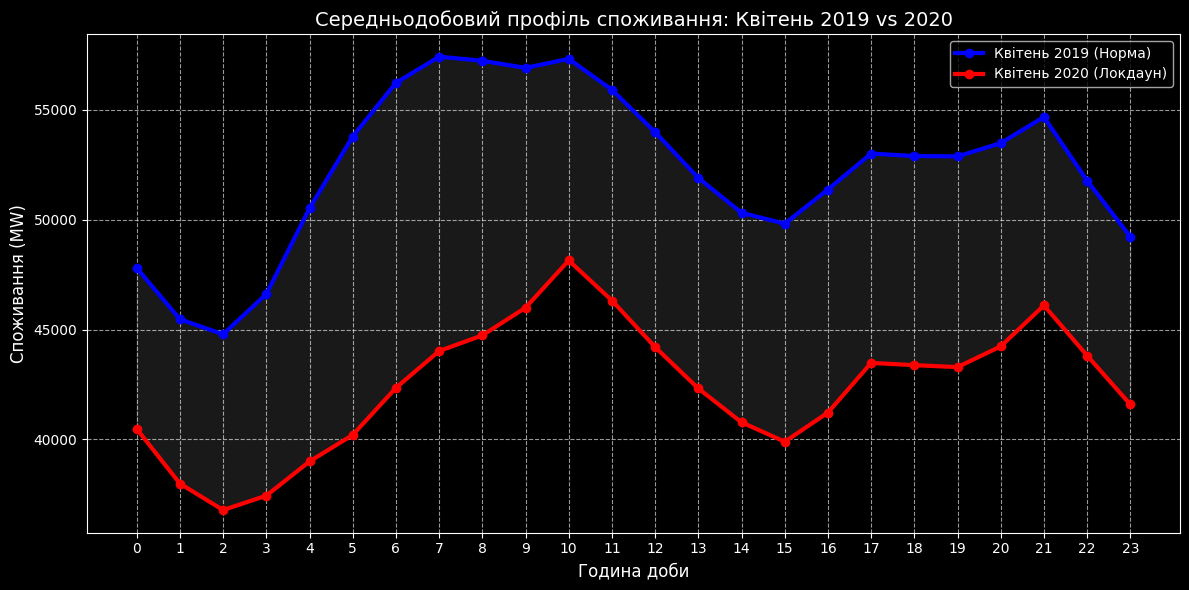

In [4]:
# 1. Підготовка даних (вибираємо тільки квітень)
# Вже маємо df_normal та df_crisis з попереднього кроку
apr_2019 = df_normal.loc['2019-04-01':'2019-04-30'].copy()
apr_2020 = df_crisis.loc['2020-04-01':'2020-04-30'].copy()

# 2. Групуємо за годинами (0-23) та рахуємо середнє
# .index.hour дозволяє виділити годину з кожної часової мітки
daily_profile_2019 = apr_2019.groupby(apr_2019.index.hour)['Energy_Consumption'].mean()
daily_profile_2020 = apr_2020.groupby(apr_2020.index.hour)['Energy_Consumption'].mean()

# 3. Візуалізація
plt.figure(figsize=(12, 6))

plt.plot(daily_profile_2019.index, daily_profile_2019.values,
         label='Квітень 2019 (Норма)', linewidth=3, marker='o', color='blue')
plt.plot(daily_profile_2020.index, daily_profile_2020.values,
         label='Квітень 2020 (Локдаун)', linewidth=3, marker='o', color='red')

# Оформлення
plt.title('Середньодобовий профіль споживання: Квітень 2019 vs 2020', fontsize=14)
plt.xlabel('Година доби', fontsize=12)
plt.ylabel('Споживання (MW)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Додаємо заливку між графіками, щоб виділити різницю
plt.fill_between(daily_profile_2019.index, daily_profile_2019.values,
                 daily_profile_2020.values, color='gray', alpha=0.2, label='Втрачене споживання')

plt.tight_layout()
plt.show()

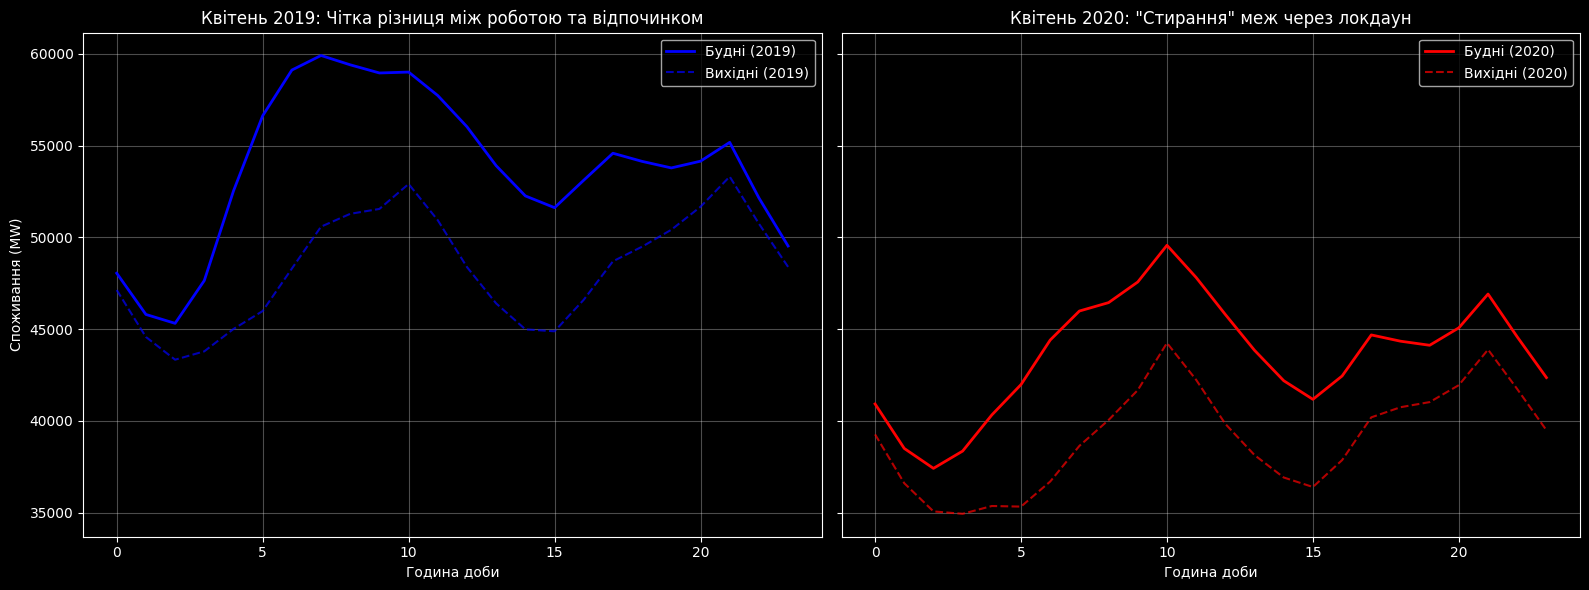

Різниця Будні/Вихідні о 12:00 (2019): 7646 MW
Різниця Будні/Вихідні о 12:00 (2020): 5962 MW
Скорочення 'ефекту буднього дня': 22.0%


In [5]:
# 1. Завантаження даних
df_normal = pd.read_csv('data/fr_energy_normal.csv', index_col=0)
df_normal.index = pd.to_datetime(df_normal.index, utc=True)

df_crisis = pd.read_csv('data/fr_energy_crisis.csv', index_col=0)
df_crisis.index = pd.to_datetime(df_crisis.index, utc=True)

# 2. Функція для створення добових профілів (будні vs вихідні)
def get_workday_weekend_profiles(df, year_month_start, year_month_end):
    # Фільтруємо період (наприклад, квітень)
    subset = df.loc[year_month_start:year_month_end].copy()

    # Визначаємо тип дня (0-4 - будні, 5-6 - вихідні)
    subset['is_weekend'] = subset.index.dayofweek >= 5

    # Групуємо за годиною та типом дня
    profiles = subset.groupby([subset.index.hour, 'is_weekend'])['Energy_Consumption'].mean().unstack()
    profiles.columns = ['Будні', 'Вихідні']
    return profiles

# 3. Отримуємо профілі для квітня 2019 та квітня 2020
profile_2019 = get_workday_weekend_profiles(df_normal, '2019-04-01', '2019-04-30')
profile_2020 = get_workday_weekend_profiles(df_crisis, '2020-04-01', '2020-04-30')

# 4. Візуалізація
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Графік 2019 (Норма)
ax1.plot(profile_2019['Будні'], label='Будні (2019)', color='blue', linewidth=2)
ax1.plot(profile_2019['Вихідні'], label='Вихідні (2019)', color='blue', linestyle='--', alpha=0.7)
ax1.set_title('Квітень 2019: Чітка різниця між роботою та відпочинком')
ax1.set_xlabel('Година доби')
ax1.set_ylabel('Споживання (MW)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Графік 2020 (Криза)
ax2.plot(profile_2020['Будні'], label='Будні (2020)', color='red', linewidth=2)
ax2.plot(profile_2020['Вихідні'], label='Вихідні (2020)', color='red', linestyle='--', alpha=0.7)
ax2.set_title('Квітень 2020: "Стирання" меж через локдаун')
ax2.set_xlabel('Година доби')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Розрахунок різниці між буднями та вихідними в обід (12:00)
gap_2019 = profile_2019.loc[12, 'Будні'] - profile_2019.loc[12, 'Вихідні']
gap_2020 = profile_2020.loc[12, 'Будні'] - profile_2020.loc[12, 'Вихідні']

print(f"Різниця Будні/Вихідні о 12:00 (2019): {gap_2019:.0f} MW")
print(f"Різниця Будні/Вихідні о 12:00 (2020): {gap_2020:.0f} MW")
print(f"Скорочення 'ефекту буднього дня': {((gap_2019 - gap_2020)/gap_2019)*100:.1f}%")

In [6]:
import numpy as np

# 1. Використовуємо вже розраховані профілі (з вашого попереднього кроку)
# profile_2019 та profile_2020

# Розрахуємо відносну різницю в % для кожної години
# Формула: ((Будні - Вихідні) / Вихідні) * 100
rel_diff_2019 = ((profile_2019['Будні'] - profile_2019['Вихідні']) / profile_2019['Вихідні']) * 100
rel_diff_2020 = ((profile_2020['Будні'] - profile_2020['Вихідні']) / profile_2020['Вихідні']) * 100

print(f"Відносна інтенсивність буднів о 10:00 (2019): {rel_diff_2019.loc[10]:.2f}%")
print(f"Відносна інтенсивність буднів о 10:00 (2020): {rel_diff_2020.loc[10]:.2f}%")

# 2. Аналіз "коефіцієнта форми" (Пік/Мінімум)
# Це показує, наскільки "динамічною" є доба. Якщо коефіцієнт падає - графік стає пласкішим.
shape_2019 = profile_2019['Будні'].max() / profile_2019['Будні'].min()
shape_2020 = profile_2020['Будні'].max() / profile_2020['Будні'].min()

print(f"\nКоефіцієнт амплітуди доби (2019): {shape_2019:.3f}")
print(f"Коефіцієнт амплітуди доби (2020): {shape_2020:.3f}")

# 3. Кореляційний аналіз
# Наскільки графік 2020 року "будні" схожий на графік 2019 року "вихідні"?
similarity = np.corrcoef(profile_2020['Будні'], profile_2019['Вихідні'])[0, 1]
print(f"\nСхожість буднів локдауну з вихідними мирного часу (кореляція): {similarity:.3f}")

Відносна інтенсивність буднів о 10:00 (2019): 11.53%
Відносна інтенсивність буднів о 10:00 (2020): 12.03%

Коефіцієнт амплітуди доби (2019): 1.322
Коефіцієнт амплітуди доби (2020): 1.325

Схожість буднів локдауну з вихідними мирного часу (кореляція): 0.909


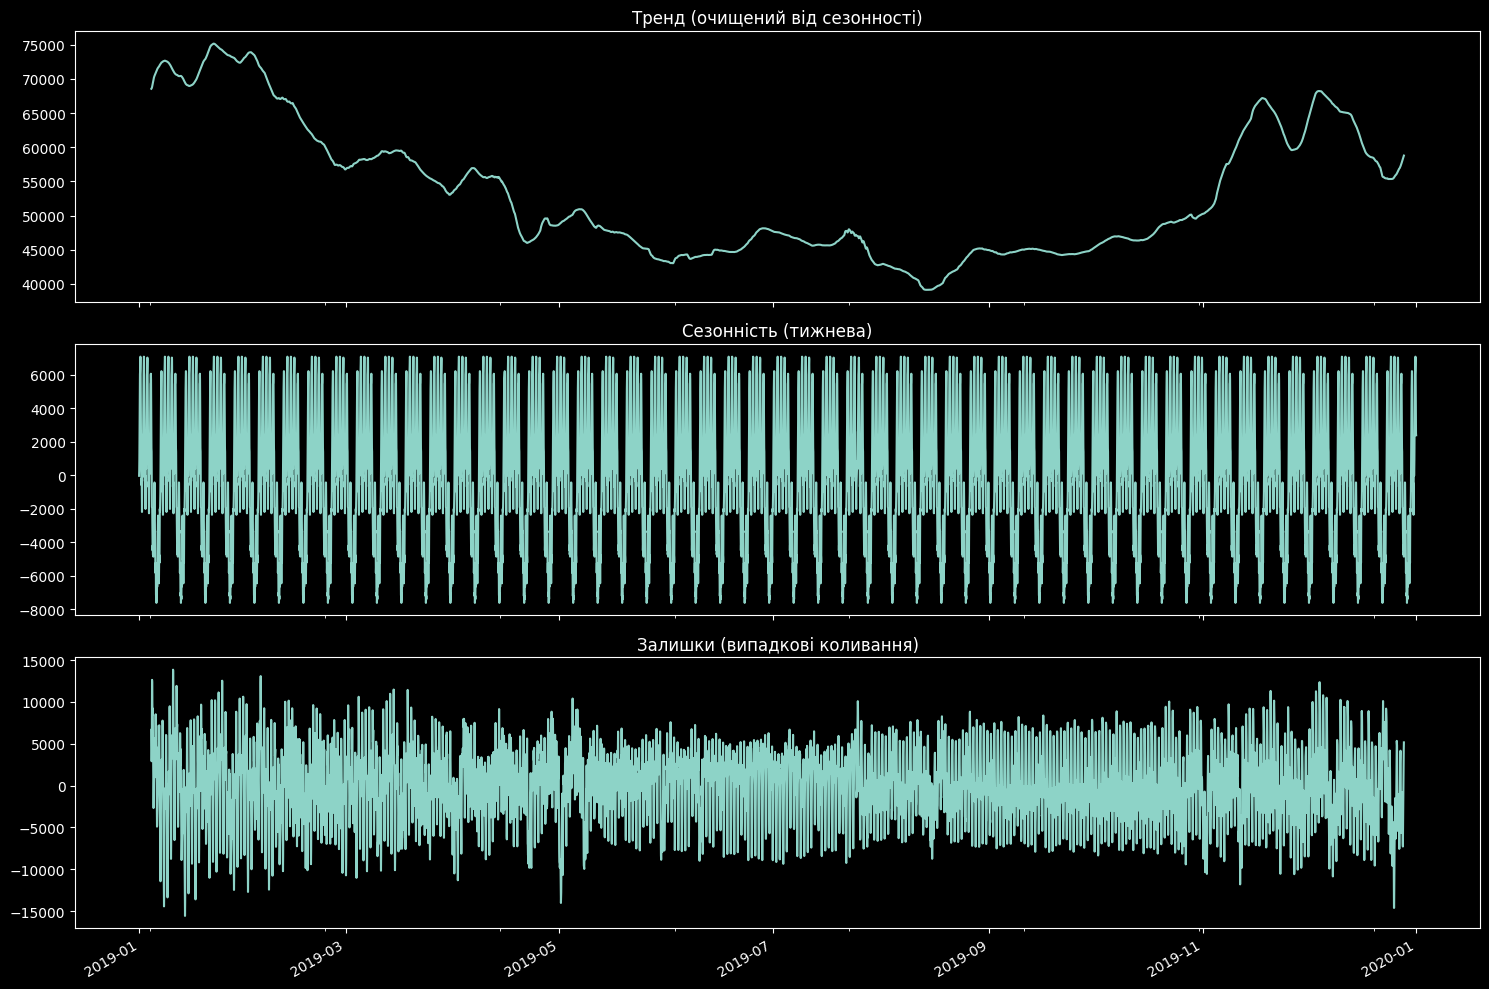

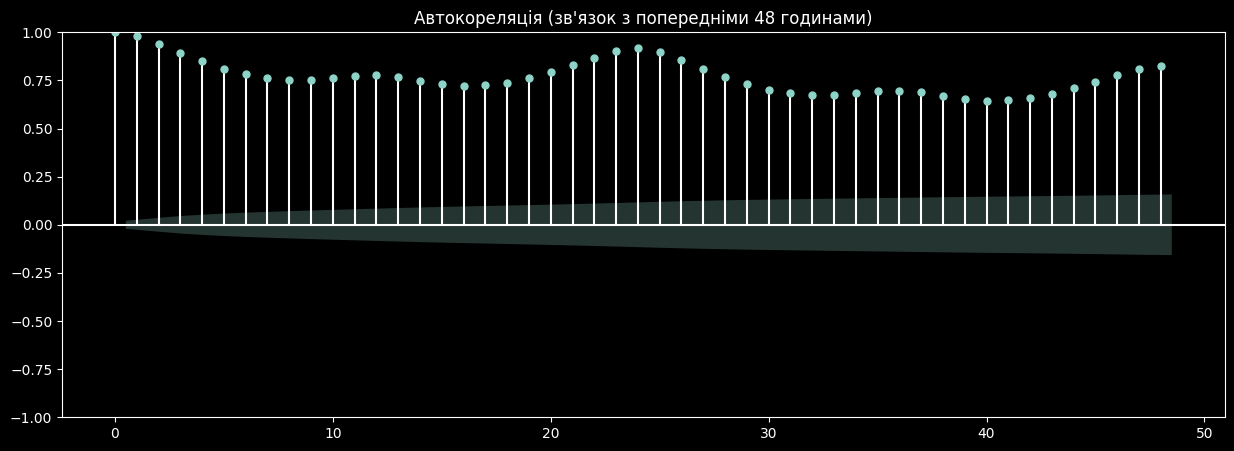

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Завантажуємо лише "нормальний" період для бази (2019 рік)
df_2019 = df_normal.loc['2019-01-01':'2019-12-31']

# 1. Декомпозиція (візьмемо тижневий період 24*7 = 168 годин)
result = seasonal_decompose(df_2019['Energy_Consumption'], model='additive', period=168)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
result.trend.plot(ax=ax1, title='Тренд (очищений від сезонності)')
result.seasonal.plot(ax=ax2, title='Сезонність (тижнева)')
result.resid.plot(ax=ax3, title='Залишки (випадкові коливання)')
plt.tight_layout()
plt.show()

# 2. Автокореляція (дивимось на зв'язок між годинами)
plt.figure(figsize=(15, 5))
plot_acf(df_2019['Energy_Consumption'], lags=48, ax=plt.gca())
plt.title('Автокореляція (зв\'язок з попередніми 48 годинами)')
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series):
    print("Результати тесту Дікі-Фуллера:")
    result = adfuller(series.dropna())

    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4e}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\nВисновок: Ряд стаціонарний (відхиляємо H0).")
    else:
        print("\nВисновок: Ряд нестаціонарний (не вдалося відхилити H0).")

# Тест на всьому стабільному періоді (2017-2019)
print("--- Тест для всього докризового періоду (2017-2019) ---")
perform_adf_test(df_normal['Energy_Consumption'])

# Для порівняння можна запустити на кризовому (цікаво, що він покаже)
print("\n--- Тест для кризового періоду (2020-2022) ---")
perform_adf_test(df_crisis['Energy_Consumption'])

--- Тест для всього докризового періоду (2017-2019) ---
Результати тесту Дікі-Фуллера:
ADF Statistic: -6.2003
p-value: 5.8298e-08
Critical Values:
	1%: -3.4306
	5%: -2.8617
	10%: -2.5668

Висновок: Ряд стаціонарний (відхиляємо H0).

--- Тест для кризового періоду (2020-2022) ---
Результати тесту Дікі-Фуллера:
ADF Statistic: -5.5702
p-value: 1.4732e-06
Critical Values:
	1%: -3.4306
	5%: -2.8617
	10%: -2.5668

Висновок: Ряд стаціонарний (відхиляємо H0).


--- Результати Наївної моделі (Квітень 2020) ---
Середня абсолютна помилка (MAE): 1928.01 MW
Відсоткова помилка (MAPE): 4.63%


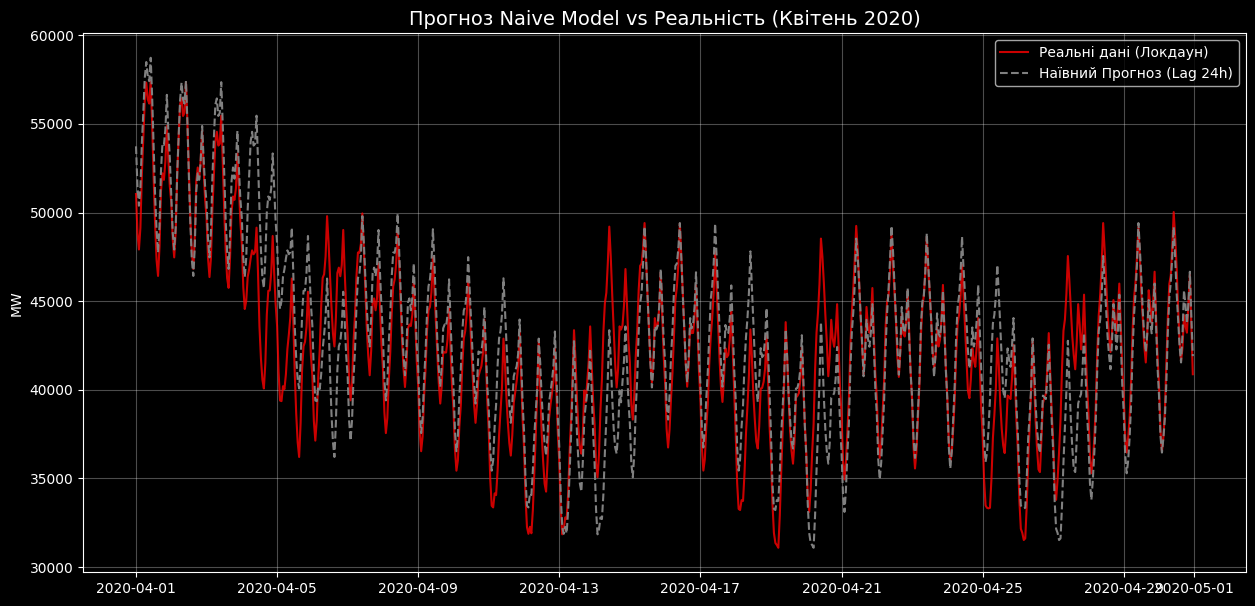

In [9]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

# 1. Готуємо дані
train = df_normal['Energy_Consumption']
test = df_crisis.loc['2020-01-01':'2020-12-31', 'Energy_Consumption']

# 2. Seasonal Naive Model (Прогноз на 24 години вперед)
# ВИПРАВЛЕНО: використовуємо .bfill() замість fillna(method='bfill')
baseline_forecast = test.shift(24).bfill()

# 3. Аналіз результатів для квітня 2020 (пік локдауну)
test_apr = test.loc['2020-04-01':'2020-04-30']
forecast_apr = baseline_forecast.loc['2020-04-01':'2020-04-30']

# Розрахунок метрик
# MAPE (Mean Absolute Percentage Error)
mape = mean_absolute_percentage_error(test_apr, forecast_apr)
# MAE (Mean Absolute Error)
mae = mean_absolute_error(test_apr, forecast_apr)

print(f"--- Результати Наївної моделі (Квітень 2020) ---")
print(f"Середня абсолютна помилка (MAE): {mae:.2f} MW")
print(f"Відсоткова помилка (MAPE): {mape:.2%}")

# 4. Візуалізація результату
plt.figure(figsize=(15, 7))
plt.plot(test_apr.index, test_apr.values, label='Реальні дані (Локдаун)', color='red', alpha=0.8)
plt.plot(test_apr.index, forecast_apr.values, label='Наївний Прогноз (Lag 24h)', color='gray', linestyle='--')
plt.title('Прогноз Naive Model vs Реальність (Квітень 2020)', fontsize=14)
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Виправляємо дані

In [10]:
def clean_and_prepare(file_path):
    # Завантаження
    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index, utc=True)

    # 1. Видалення дублікатів (важливо для стабільності індексу)
    df = df[~df.index.duplicated(keep='first')]

    # 2. Створення регулярної сітки (Hourly Frequency)
    # Змінено 'H' на 'h' для сумісності з новими версіями pandas
    df = df.asfreq('h')

    # 3. Лінійна інтерполяція
    df['Energy_Consumption'] = df['Energy_Consumption'].interpolate(method='linear', limit_direction='both')

    return df

# Очищуємо наші основні змінні
df_normal = clean_and_prepare('data/fr_energy_normal.csv')
df_crisis = clean_and_prepare('data/fr_energy_crisis.csv')

print("Дані очищені: дублікати видалені, часова сітка відновлена, пропуски інтерпольовані.")
print(f"Частота ряду: {df_normal.index.freq}")

Дані очищені: дублікати видалені, часова сітка відновлена, пропуски інтерпольовані.
Частота ряду: <Hour>


In [11]:
import pmdarima as pm

# Беремо квартал для підбору параметрів
train_slice = df_normal.loc['2019-10-01':'2019-12-31', 'Energy_Consumption']

print(f"Починаємо підбір SARIMA на проміжку: {train_slice.index.min()} - {train_slice.index.max()}")

model_sarima = pm.auto_arima(
    train_slice,
    seasonal=True,
    m=24,                # Добова сезонність
    stepwise=True,       # Прискорює пошук
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
    max_p=3, max_q=3,    # Обмежуємо складність, щоб не чекати вічність
    max_P=2, max_Q=2
)

print(model_sarima.summary())

Починаємо підбір SARIMA на проміжку: 2019-10-01 00:00:00+00:00 - 2019-12-31 22:00:00+00:00
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=36033.937, Time=12.20 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=40534.462, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=37700.089, Time=3.62 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=40532.520, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[24] intercept   : AIC=37607.116, Time=10.85 sec
 ARIMA(2,1,2)(1,0,0)[24] intercept   : AIC=inf, Time=14.34 sec
 ARIMA(2,1,2)(2,0,1)[24] intercept   : AIC=inf, Time=45.62 sec
 ARIMA(2,1,2)(1,0,2)[24] intercept   : AIC=inf, Time=47.54 sec
 ARIMA(2,1,2)(0,0,0)[24] intercept   : AIC=38902.630, Time=0.99 sec
 ARIMA(2,1,2)(0,0,2)[24] intercept   : AIC=37417.417, Time=35.93 sec
 ARIMA(2,1,2)(2,0,0)[24] intercept   : AIC=36338.386, Time=55.26 sec
 ARIMA(2,1,2)(2,0,2)[24] intercept   : AIC=inf, Time=54.93 sec
 ARIM

Навчання SARIMA (Квітень 2018 - Березень 2019)...
Optimization terminated successfully.
         Current function value: 7.765479
         Iterations: 4
         Function evaluations: 267
------------------------------
Справжній фінальний MAPE для квітня 2019: 32.24%
------------------------------


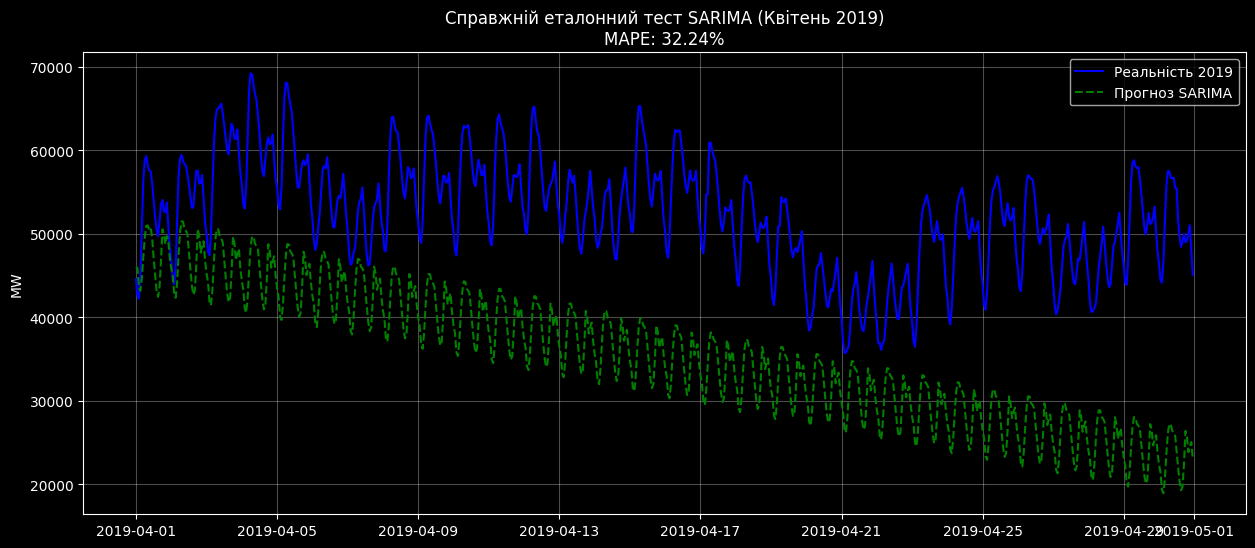

In [16]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Правильна підготовка даних (навчання до 31 березня 2019)
train_normal = df_normal.loc['2018-04-01':'2019-03-31', 'Energy_Consumption']
test_2019 = df_normal.loc['2019-04-01':'2019-04-30', 'Energy_Consumption']

print("Навчання SARIMA (Квітень 2018 - Березень 2019)...")

# 2. Навчання з нашими найкращими параметрами
model_final = SARIMAX(train_normal,
                      order=(2, 1, 0),
                      seasonal_order=(1, 0, 2, 24),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

model_fit_final = model_final.fit(disp=True, maxiter=50, method='powell', low_memory=True)

# 3. Прогноз (тепер він почнеться рівно з 1 квітня 2019)
forecast_res = model_fit_final.get_forecast(steps=len(test_2019))
forecast_values = forecast_res.predicted_mean

# 4. Результат
mape_2019 = mean_absolute_percentage_error(test_2019, forecast_values)

print("-" * 30)
print(f"Справжній фінальний MAPE для квітня 2019: {mape_2019:.2%}")
print("-" * 30)

# Візуалізація
plt.figure(figsize=(15, 6))
plt.plot(test_2019.index, test_2019.values, label='Реальність 2019', color='blue')
plt.plot(test_2019.index, forecast_values.values, label='Прогноз SARIMA', color='green', linestyle='--')
plt.title(f'Справжній еталонний тест SARIMA (Квітень 2019)\nMAPE: {mape_2019:.2%}')
plt.ylabel('MW')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# 1. Беремо 1 рік для навчання (2018), щоб зекономити пам'ять
train_normal_light = df_normal.loc['2018-01-01':'2018-12-31', 'Energy_Consumption']
test_normal = df_normal.loc['2019-04-01':'2019-04-30', 'Energy_Consumption']

print(f"Навчання на 2018 році (точок: {len(train_normal_light)})...")

model_normal = SARIMAX(train_normal_light,
                       order=(2, 1, 1),
                       seasonal_order=(2, 0, 0, 24),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# 2. Додаємо low_memory=True у метод fit
model_fit_normal = model_normal.fit(disp=False, low_memory=True)

# Далі прогноз як зазвичай
forecast_normal = model_fit_normal.get_forecast(steps=len(test_normal))
forecast_values_normal = forecast_normal.predicted_mean
forecast_values_normal.index = test_normal.index

mape_2019 = mean_absolute_percentage_error(test_normal, forecast_values_normal)
print(f"--- Результат контрольного тесту (Навчання на 1 році) ---")
print(f"MAPE для квітня 2019: {mape_2019:.2%}")

Навчання на 2018 році (точок: 8760)...
--- Результат контрольного тесту (Навчання на 1 році) ---
MAPE для квітня 2019: 16.02%
